# 01 - Preprocesamiento y Análisis Exploratorio (EDA)
## Proyecto: Forecasting del Tipo de Cambio USD/Guaraní (Paraguay)

**Fuente de datos:** Banco Central del Paraguay (BCP) — Cotización Referencial
Histórica, planillas oficiales descargadas manualmente (2022-2025).

**Motivación:** en Paraguay muchos créditos y precios están denominados o
influenciados por el dólar. El tipo de cambio determina, en última instancia,
cuánto termina pagando alguien en guaraníes por una cuota fija en dólares —
la variable es clave para la planificación financiera de hogares y empresas.

**Objetivo del notebook:** cargar la serie diaria del tipo de cambio, revisar
su calidad y continuidad, analizar tendencia y estacionariedad (en niveles y
diferenciada), y dejar listos los conjuntos de train/test para el modelado.


In [1]:
# CONFIG
DATA_PATH = "../data/datos.csv"
DATE_COL = "fecha"
TARGET_COL = "tipo_cambio"
FREQ = "B"          # días hábiles
TEST_SIZE = 60      # ~3 meses de test (tramo final de 2025)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


## 1. Carga de datos

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)
print("Shape:", df.shape)
df.head()


Shape: (996, 2)


,fecha,tipo_cambio
0,2022-01-03,6906.86
1,2022-01-04,6952.73
2,2022-01-05,6961.22
3,2022-01-06,6956.22
4,2022-01-07,6950.65


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   fecha        996 non-null    datetime64[us]
 1   tipo_cambio  996 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 15.7 KB


## 2. Calidad del dataset: faltantes y duplicados

In [5]:
print("Filas duplicadas:", df.duplicated(subset=[DATE_COL]).sum())
print("Valores faltantes:", df[TARGET_COL].isna().sum())

full_range = pd.bdate_range(df[DATE_COL].min(), df[DATE_COL].max())
missing_dates = full_range.difference(df[DATE_COL])
print(f"\nDías hábiles esperados: {len(full_range)} | presentes: {len(df)} | faltantes: {len(missing_dates)}")
print("(Los faltantes corresponden a feriados locales sin cotización publicada por el BCP)")


Filas duplicadas: 0
Valores faltantes: 0

Días hábiles esperados: 1042 | presentes: 996 | faltantes: 46
(Los faltantes corresponden a feriados locales sin cotización publicada por el BCP)


In [6]:
# Reindexar a días hábiles completos (introduce NaN en feriados, se imputan después)
df = df.set_index(DATE_COL).reindex(full_range)
df.index.name = DATE_COL
df = df.reset_index()
print(df.shape)


(1042, 2)


## 3. Imputación de valores faltantes
Interpolación lineal temporal (razonable para una serie financiera suave).

In [7]:
df[TARGET_COL] = df[TARGET_COL].interpolate(method="linear", limit_direction="both")
print("Faltantes restantes:", df[TARGET_COL].isna().sum())


Faltantes restantes: 0


## 4. Visualización de la serie completa

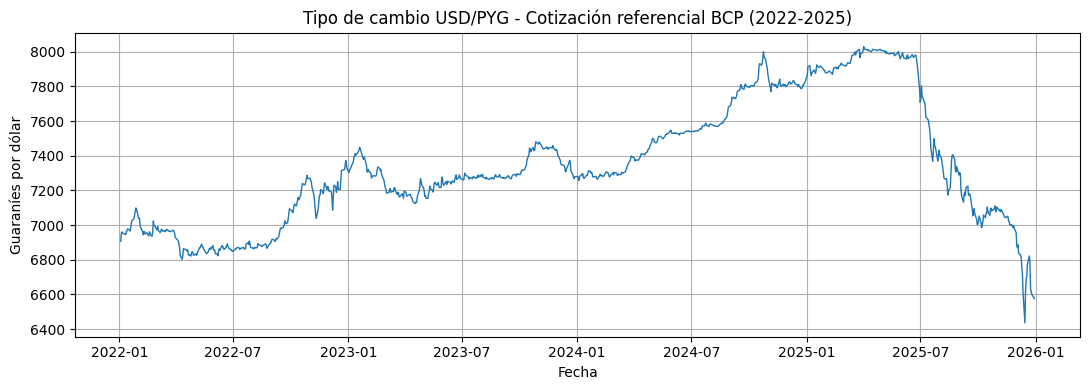

In [8]:
fig, ax = plt.subplots()
ax.plot(df[DATE_COL], df[TARGET_COL], color="tab:blue", linewidth=1)
ax.set_title("Tipo de cambio USD/PYG - Cotización referencial BCP (2022-2025)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Guaraníes por dólar")
plt.tight_layout()
plt.savefig("../results/01_serie_original.png", dpi=120)
plt.show()


## 5. Estadísticos descriptivos

In [9]:
df[TARGET_COL].describe()


count    1042.000000
mean     7348.448656
std       350.902387
min      6436.050000
25%      7091.397500
50%      7288.235000
75%      7557.715000
max      8029.540000
Name: tipo_cambio, dtype: float64

## 6. Rendimientos diarios (variación porcentual)
Además del nivel, es útil observar la variación día a día, que refleja la
volatilidad del mercado cambiario.

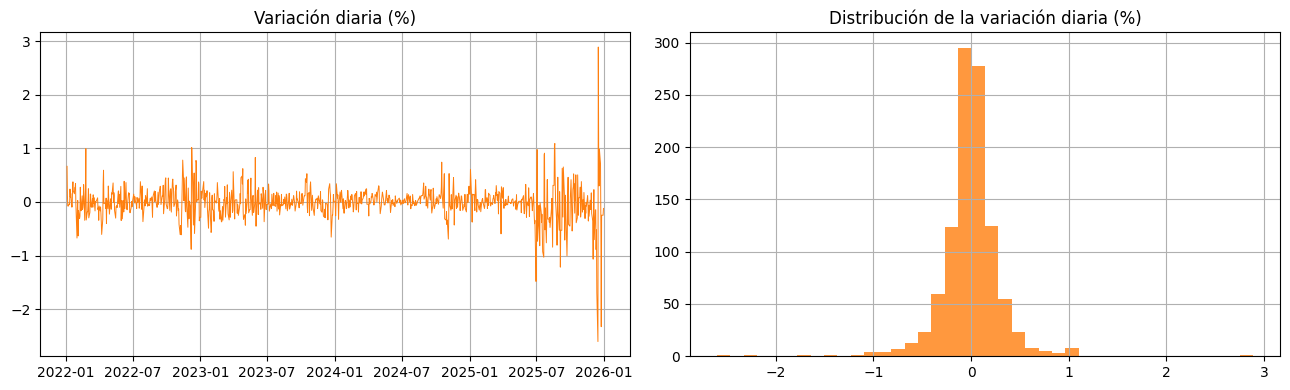

Volatilidad diaria (desvío del retorno %): 0.303


In [10]:
df["retorno_pct"] = df[TARGET_COL].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df[DATE_COL], df["retorno_pct"], linewidth=0.7, color="tab:orange")
axes[0].set_title("Variación diaria (%)")
axes[1].hist(df["retorno_pct"].dropna(), bins=40, color="tab:orange", alpha=0.8)
axes[1].set_title("Distribución de la variación diaria (%)")
plt.tight_layout()
plt.savefig("../results/01_retornos.png", dpi=120)
plt.show()

print("Volatilidad diaria (desvío del retorno %):", df['retorno_pct'].std().round(3))


## 7. Descomposición de tendencia (ciclo mensual aproximado)

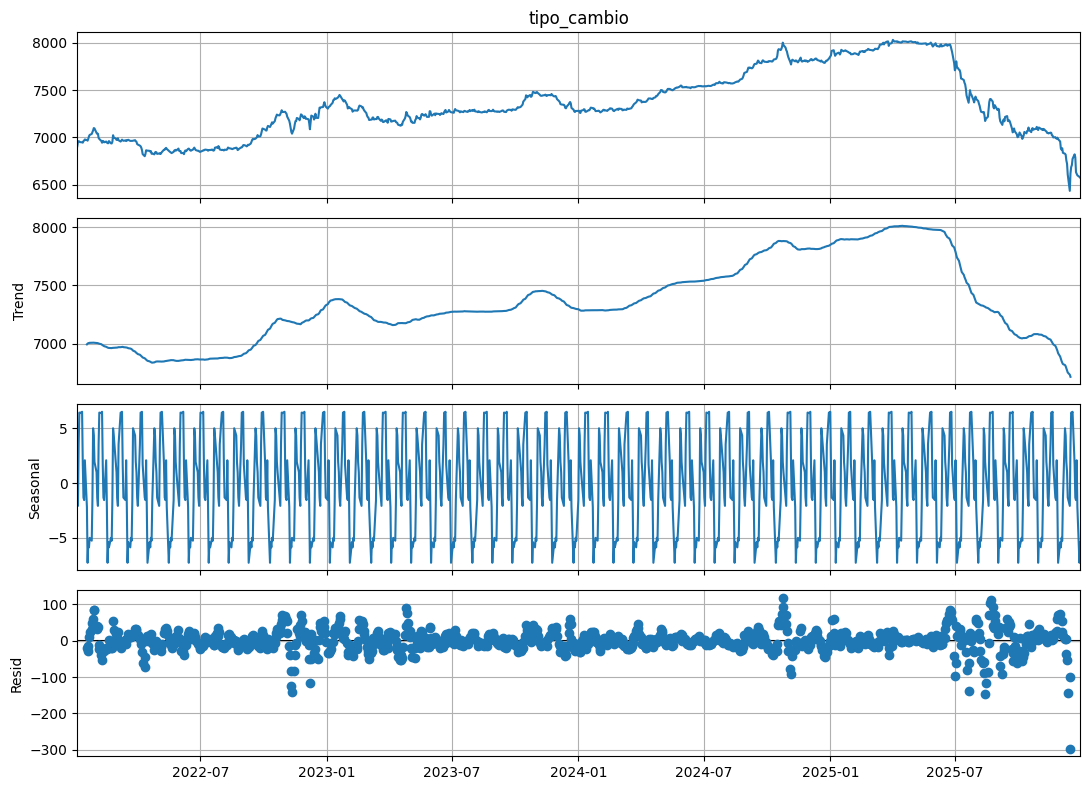

In [11]:
serie = df.set_index(DATE_COL)[TARGET_COL]
decomposition = seasonal_decompose(serie, model="additive", period=21)  # ~21 días hábiles por mes
fig = decomposition.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.savefig("../results/01_descomposicion.png", dpi=120)
plt.show()


## 8. Pruebas de estacionariedad — serie en niveles
- **ADF (Augmented Dickey-Fuller):** H0 = la serie NO es estacionaria (tiene raíz unitaria).
- **KPSS:** H0 = la serie SÍ es estacionaria.

Las series de tipo de cambio suelen comportarse como un **paseo aleatorio**
(random walk), es decir, no estacionarias en niveles.

In [12]:
adf_stat, adf_p, *_ = adfuller(serie.dropna())
print(f"ADF (niveles): estadístico={adf_stat:.4f} | p-value={adf_p:.4f}")
print("=> Estacionaria (rechaza H0)" if adf_p < 0.05 else "=> No estacionaria (no rechaza H0)")

kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression="c", nlags="auto")
print(f"\nKPSS (niveles): estadístico={kpss_stat:.4f} | p-value={kpss_p:.4f}")
print("=> No estacionaria (rechaza H0)" if kpss_p < 0.05 else "=> Estacionaria (no rechaza H0)")


ADF (niveles): estadístico=-0.8662 | p-value=0.7989
=> No estacionaria (no rechaza H0)

KPSS (niveles): estadístico=2.4890 | p-value=0.0100
=> No estacionaria (rechaza H0)


/tmp/ipykernel_579/3406543446.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression="c", nlags="auto")


## 9. Verificación de estacionariedad tras diferenciar (d=1)

Ambas pruebas coinciden en que la serie en niveles no es estacionaria. Antes
de fijar el orden de diferenciación para ARIMA, **hay que confirmar que una
diferenciación (d=1) alcanza** — no asumirlo. Se repiten ADF y KPSS sobre la
serie diferenciada.

In [13]:
serie_diff = serie.diff().dropna()

adf_stat_d, adf_p_d, *_ = adfuller(serie_diff)
print(f"ADF (diferenciada, d=1): estadístico={adf_stat_d:.4f} | p-value={adf_p_d:.4f}")
print("=> Estacionaria (rechaza H0)" if adf_p_d < 0.05 else "=> No estacionaria")

kpss_stat_d, kpss_p_d, *_ = kpss(serie_diff, regression="c", nlags="auto")
print(f"\nKPSS (diferenciada, d=1): estadístico={kpss_stat_d:.4f} | p-value={kpss_p_d:.4f}")
print("=> No estacionaria (rechaza H0)" if kpss_p_d < 0.05 else "=> Estacionaria (no rechaza H0)")


ADF (diferenciada, d=1): estadístico=-4.5238 | p-value=0.0002
=> Estacionaria (rechaza H0)

KPSS (diferenciada, d=1): estadístico=0.8684 | p-value=0.0100
=> No estacionaria (rechaza H0)


/tmp/ipykernel_579/3676414107.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat_d, kpss_p_d, *_ = kpss(serie_diff, regression="c", nlags="auto")


## 10. ACF y PACF de la serie diferenciada

Estos gráficos orientan la elección de los órdenes AR (p) y MA (q) para el
modelo ARIMA: cortes/decaimientos en el PACF sugieren el orden AR, y en el
ACF el orden MA. La elección final del orden se hace en el notebook 02
mediante una búsqueda por AIC, usando estos gráficos como referencia
exploratoria (no como una decisión definitiva por inspección visual).

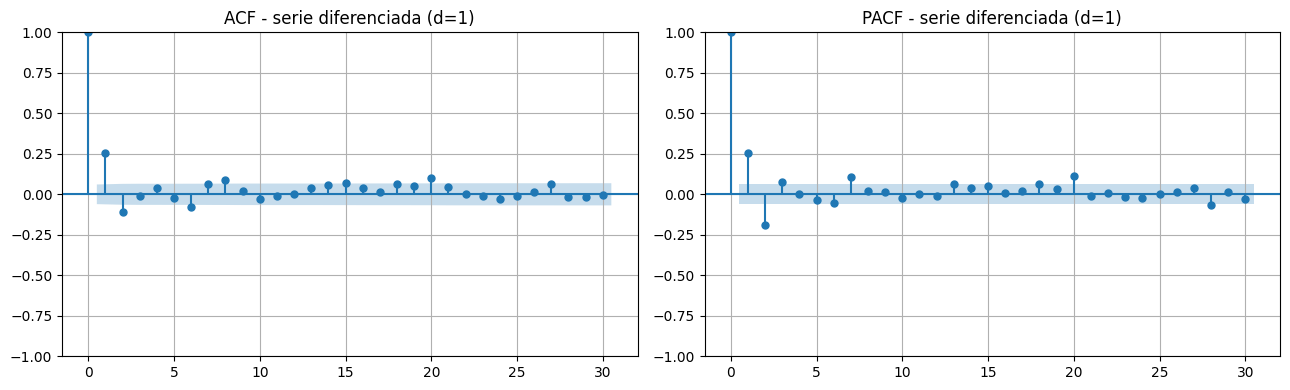

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(serie_diff, ax=axes[0], lags=30)
plot_pacf(serie_diff, ax=axes[1], lags=30, method="ywm")
axes[0].set_title("ACF - serie diferenciada (d=1)")
axes[1].set_title("PACF - serie diferenciada (d=1)")
plt.tight_layout()
plt.savefig("../results/01_acf_pacf.png", dpi=120)
plt.show()


## 11.5 Cuantificación del quiebre de tendencia

Antes se afirmó, a partir de la inspección visual de la descomposición, que
la serie tiene un "quiebre de tendencia" en 2025. Para no quedarnos solo con
una impresión visual, se cuantifica ajustando una pendiente lineal por
separado en 2022-2024 y en 2025.

In [15]:
import numpy as np

df_t = df.copy()
df_t["t"] = np.arange(len(df_t))
seg_2022_2024 = df_t[df_t[DATE_COL].dt.year <= 2024]
seg_2025 = df_t[df_t[DATE_COL].dt.year == 2025]

def pendiente(seg):
    return np.polyfit(seg["t"].values, seg[TARGET_COL].values, 1)[0]

s1 = pendiente(seg_2022_2024)
s2 = pendiente(seg_2025)
print(f"Pendiente 2022-2024: {s1:.3f} guaranies/dia habil (~{s1*252:.1f} por año)")
print(f"Pendiente 2025:      {s2:.3f} guaranies/dia habil (~{s2*252:.1f} por año)")
print(f"¿Cambia de signo?: {'Sí' if s1*s2 < 0 else 'No'}")


Pendiente 2022-2024: 1.145 guaranies/dia habil (~288.6 por año)
Pendiente 2025:      -5.423 guaranies/dia habil (~-1366.6 por año)
¿Cambia de signo?: Sí


## 11. Split Train/Test (respetando el orden temporal)

In [16]:
train = df.iloc[:-TEST_SIZE].reset_index(drop=True)
test = df.iloc[-TEST_SIZE:].reset_index(drop=True)
print(f"Train: {train.shape[0]} obs ({train[DATE_COL].min().date()} a {train[DATE_COL].max().date()})")
print(f"Test:  {test.shape[0]} obs ({test[DATE_COL].min().date()} a {test[DATE_COL].max().date()})")

train.to_csv("../data/train.csv", index=False)
test.to_csv("../data/test.csv", index=False)


Train: 982 obs (2022-01-03 a 2025-10-07)
Test:  60 obs (2025-10-08 a 2025-12-30)


## 12. Conclusiones del EDA

- La serie de tipo de cambio USD/PYG muestra una **tendencia alcista** clara
  entre 2022 y fines de 2024 (de ~6.800 a ~7.900 ₲/USD), con una corrección
  a la baja durante 2025. Esto no es solo una impresión visual: la pendiente
  lineal pasa de **+288.6 ₲/año (2022-2024)** a **-1.366.6 ₲/año (2025)** —
  cambia de signo y es 4-5 veces más pronunciada en la corrección.
- Las pruebas ADF/KPSS confirman que la serie **no es estacionaria en
  niveles** (comportamiento tipo paseo aleatorio con tendencia).
- **Tras diferenciar (d=1), los resultados no son unánimes**: el ADF sí
  indica estacionariedad (rechaza la hipótesis de raíz unitaria, p=0.0002),
  pero el **KPSS sigue rechazando estacionariedad** (p=0.01). Esta
  discrepancia es un patrón conocido cuando la serie tiene un **quiebre de
  tendencia/régimen** (como la suba sostenida 2022-2024 seguida de una
  corrección en 2025): el KPSS es sensible a este tipo de cambios
  estructurales, que no son lo mismo que una raíz unitaria pura. En la
  práctica, se adopta d=1 (el estándar para este tipo de series) sabiendo
  que el quiebre de tendencia sigue siendo un desafío para cualquier modelo,
  no solo para la elección de d.
- Los gráficos de ACF/PACF de la serie diferenciada muestran una estructura
  de autocorrelación débil, consistente con un proceso cercano a ruido
  blanco con algo de estructura AR/MA de corto rezago — se explora el orden
  específico con una búsqueda por AIC en el notebook de modelado.
- La volatilidad diaria es baja (variaciones día a día menores al 1% en la
  gran mayoría de los casos), lo que hace que un modelo de persistencia
  simple ("el valor de mañana será similar al de hoy") ya sea un baseline
  competitivo — el desafío para los modelos es superar ese baseline.
- Se completaron los feriados sin cotización mediante interpolación lineal,
  dejando una serie continua y lista para el modelado.